In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)
from scipy.special import softmax
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# ============================================
# FINBERT SETUP — LOCAL CACHE FIRST
# Points to local cache to avoid re-downloading
# ============================================

MODEL_NAME = "ProsusAI/finbert"
MODEL_DIR  = "../models/finbert"

os.makedirs(MODEL_DIR, exist_ok=True)

print(f"Loading FinBERT from local cache...")
print(f"Cache directory: {MODEL_DIR}")

# Check if model files already exist locally
model_files = os.listdir(MODEL_DIR) \
    if os.path.exists(MODEL_DIR) else []
print(f"Files in cache: {len(model_files)}")

# Load from local cache first — only downloads
# if not already present
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    cache_dir=MODEL_DIR,
    local_files_only=True  # Set True after first download
)
model = AutoModelForSequenceClassification\
    .from_pretrained(
    MODEL_NAME,
    cache_dir=MODEL_DIR,
    local_files_only=False
)
model.eval()

# Device detection
if torch.cuda.is_available():
    device = "cuda"
    print(f"GPU: {torch.cuda.get_device_name(0)}")
elif hasattr(torch.backends, "mps") and \
        torch.backends.mps.is_available():
    device = "mps"
    print("Apple Silicon GPU detected")
else:
    device = "cpu"
    print("CPU mode — ~30 seconds for 95 transcripts")

model = model.to(device)

LABEL_MAP = model.config.id2label

print(f"\nFinBERT ready")
print(f"Device:     {device}")
print(f"Labels:     {LABEL_MAP}")
print(f"Parameters: "
      f"{sum(p.numel() for p in model.parameters())/1e6:.0f}M")

# Load data
df = pd.read_csv(
    "../data/processed/sentiment_vader.csv",
    parse_dates=["date"]
)

TICKER_COLORS = {
    "AAPL": "#378ADD",
    "MSFT": "#1D9E75",
    "TSLA": "#D85A30",
    "JPM":  "#7F77DD",
    "NVDA": "#BA7517"
}

print(f"\nData loaded: {len(df)} transcripts")

Loading FinBERT from local cache...
Cache directory: ../models/finbert
Files in cache: 3


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

CPU mode — ~30 seconds for 95 transcripts

FinBERT ready
Device:     cpu
Labels:     {0: 'positive', 1: 'negative', 2: 'neutral'}
Parameters: 109M

Data loaded: 95 transcripts


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

In [2]:
def run_finbert_document(
        text: str,
        max_length: int = 512) -> dict:
    """
    Run FinBERT on a text document.
    Handles texts longer than 512 tokens
    by chunking and averaging probabilities.

    Returns:
        positive, negative, neutral probabilities
        finbert_score = positive - negative
        finbert_confidence = max prob - 0.333
        finbert_label = dominant sentiment
    """
    if not isinstance(text, str) or len(text) < 10:
        return {
            "finbert_positive":   0.333,
            "finbert_negative":   0.333,
            "finbert_neutral":    0.334,
            "finbert_score":      0.0,
            "finbert_confidence": 0.0,
            "finbert_label":      "neutral",
        }

    # Tokenise to check length
    tokens = tokenizer.encode(
        text, add_special_tokens=True)

    if len(tokens) <= max_length:
        # Single pass
        chunks = [text]
    else:
        # Chunk into overlapping segments
        # Each chunk = ~350 words with 50 word overlap
        words      = text.split()
        chunk_size = 350
        overlap    = 50
        chunks     = []
        i          = 0
        while i < len(words):
            chunk = " ".join(
                words[i:i + chunk_size])
            chunks.append(chunk)
            i += chunk_size - overlap
            if i >= len(words):
                break

    # Run inference on each chunk
    all_probs = []
    for chunk in chunks:
        inputs = tokenizer(
            chunk,
            return_tensors="pt",
            max_length=max_length,
            truncation=True,
            padding=True
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            logits  = outputs.logits

        probs = softmax(
            logits.cpu().numpy()[0])
        all_probs.append(probs)

    # Average probabilities across chunks
    avg_probs = np.mean(all_probs, axis=0)

    # Map to label names
    prob_dict = {
        LABEL_MAP[i]: float(avg_probs[i])
        for i in range(len(avg_probs))
    }

    pos  = prob_dict.get("positive", 0)
    neg  = prob_dict.get("negative", 0)
    neu  = prob_dict.get("neutral",  0)

    # Confidence: how far from uniform (0.333)
    confidence = float(max(avg_probs)) - 0.333

    # Dominant label
    label = max(prob_dict, key=prob_dict.get)

    return {
        "finbert_positive":   round(pos,  4),
        "finbert_negative":   round(neg,  4),
        "finbert_neutral":    round(neu,  4),
        "finbert_score":      round(pos - neg, 4),
        "finbert_confidence": round(confidence, 4),
        "finbert_label":      label,
    }


def run_finbert_sentences(
        text: str,
        max_sents: int = 10) -> dict:
    """
    Run FinBERT on individual sentences.
    Returns aggregated sentence-level metrics.
    Captures intra-document sentiment variation.
    """
    from nltk.tokenize import sent_tokenize
    import nltk
    nltk.download("punkt", quiet=True)
    nltk.download("punkt_tab", quiet=True)

    sentences = sent_tokenize(text)
    # Filter short sentences
    sentences = [s for s in sentences
                 if len(s.split()) >= 5]

    if not sentences:
        return {
            "finbert_sent_mean":    0.0,
            "finbert_sent_std":     0.0,
            "finbert_sent_min":     0.0,
            "finbert_sent_max":     0.0,
            "finbert_pct_pos":      0.0,
            "finbert_pct_neg":      0.0,
            "finbert_sent_range":   0.0,
        }

    # Sample sentences if too many
    if len(sentences) > max_sents:
        step = len(sentences) // max_sents
        sentences = sentences[::step][:max_sents]

    sent_scores = []
    for sent in sentences:
        result = run_finbert_document(sent)
        sent_scores.append(result["finbert_score"])

    scores_arr = np.array(sent_scores)

    return {
        "finbert_sent_mean":  round(float(scores_arr.mean()), 4),
        "finbert_sent_std":   round(float(scores_arr.std()), 4),
        "finbert_sent_min":   round(float(scores_arr.min()), 4),
        "finbert_sent_max":   round(float(scores_arr.max()), 4),
        "finbert_pct_pos":    round(float((scores_arr > 0.1).mean()), 4),
        "finbert_pct_neg":    round(float((scores_arr < -0.1).mean()), 4),
        "finbert_sent_range": round(float(scores_arr.max() - scores_arr.min()), 4),
    }

print("FinBERT inference functions defined")
print("Features per transcript:")
print("  Document level: positive, negative, neutral,")
print("                  score, confidence, label")
print("  Sentence level: mean, std, min, max,")
print("                  pct_positive, pct_negative, range")

FinBERT inference functions defined
Features per transcript:
  Document level: positive, negative, neutral,
                  score, confidence, label
  Sentence level: mean, std, min, max,
                  pct_positive, pct_negative, range


In [3]:
# ============================================
# RUN FINBERT ON ALL TRANSCRIPTS
# Document level + sentence level
# ============================================
print(f"Running FinBERT on {len(df)} transcripts...")
print(f"Device: {device}")
print(f"Estimated time: "
      f"{'~30s' if device=='cpu' else '~10s'}")
print()

doc_results  = []
sent_results = []

for i, row in df.iterrows():
    text = str(row.get("text_clean", ""))

    if not text or len(text) < 20:
        text = str(row.get("text", ""))

    # Progress indicator every 10 transcripts
    if i % 10 == 0:
        pct = i / len(df) * 100
        print(f"  Progress: {i}/{len(df)} "
              f"({pct:.0f}%)", end="\r")

    # Document level
    doc_res = run_finbert_document(text)
    doc_res["ticker"]  = row["ticker"]
    doc_res["date"]    = row["date"]
    doc_res["quarter"] = row["quarter"]
    doc_res["tone"]    = row["tone"]
    doc_results.append(doc_res)

    # Sentence level
    sent_res = run_finbert_sentences(text)
    sent_res["ticker"]  = row["ticker"]
    sent_res["date"]    = row["date"]
    sent_results.append(sent_res)

print(f"  Progress: {len(df)}/{len(df)} (100%)  ")
print("\nFinBERT complete")

# Build DataFrames
doc_df  = pd.DataFrame(doc_results)
sent_df = pd.DataFrame(sent_results)

print("=" * 55)
print("   FINBERT RESULTS SUMMARY")
print("=" * 55)
print(f"\nDocument-level score by company:")
company_finbert = doc_df.groupby("ticker")[
    "finbert_score"
].agg(["mean","std","min","max"]).round(4)
print(company_finbert.to_string())

print(f"\nFinBERT label distribution:")
print(doc_df["finbert_label"].value_counts().to_string())

print(f"\nDocument-level score by tone:")
tone_finbert = doc_df.groupby("tone")[
    "finbert_score"
].agg(["mean","std"]).round(4)
print(tone_finbert.to_string())
print("=" * 55)

Running FinBERT on 95 transcripts...
Device: cpu
Estimated time: ~30s

  Progress: 0/95 (0%)

[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading punkt_tab: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading punkt_tab: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading punkt_tab: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading punkt_tab: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading punkt_tab: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


  Progress: 10/95 (11%)

[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading punkt_tab: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading punkt_tab: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading punkt_tab: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


  Progress: 95/95 (100%)  

FinBERT complete
   FINBERT RESULTS SUMMARY

Document-level score by company:
          mean     std     min     max
ticker                                
AAPL    0.8527  0.2351  0.1539  0.9377
JPM     0.7607  0.2193  0.4221  0.9406
MSFT    0.5411  0.6328 -0.4975  0.9250
NVDA    0.8238  0.0610  0.7734  0.9241
TSLA    0.4081  0.7655 -0.8364  0.9384

FinBERT label distribution:
finbert_label
positive    83
negative    10
neutral      2

Document-level score by tone:
            mean     std
tone                    
cautious -0.2231  0.6555
mixed     0.5488  0.5124
positive  0.8984  0.0636


In [4]:
# ============================================
# VADER VS FINBERT COMPARISON
# Where they agree = robust signal
# Where they diverge = domain-specific language
# Divergence is often the most valuable signal
# ============================================

# Merge with VADER scores
compare_df = doc_df.merge(
    df[["ticker","date","vader_compound",
        "vader_sent_mean","uncertain_ratio",
        "net_tone_ratio","vader_compound_change"]],
    on=["ticker","date"],
    how="left"
)
compare_df["date"] = pd.to_datetime(
    compare_df["date"])

# Correlation between models
corr, pval = stats.pearsonr(
    compare_df["vader_compound"].dropna(),
    compare_df["finbert_score"].dropna()
)

print("=" * 60)
print("   VADER vs FINBERT COMPARISON")
print("=" * 60)
print(f"\n  Pearson correlation: {corr:.4f} "
      f"(p={pval:.4f})")

if corr > 0.7:
    print(f"  Interpretation: Strong agreement")
    print(f"  Both models capture same signal")
elif corr > 0.4:
    print(f"  Interpretation: Moderate agreement")
    print(f"  FinBERT adds domain-specific signal")
else:
    print(f"  Interpretation: Low agreement")
    print(f"  FinBERT and VADER see different things")

# Find largest divergences
compare_df["model_divergence"] = (
    compare_df["finbert_score"] -
    compare_df["vader_compound"]
)

print(f"\n  Largest positive divergences")
print(f"  (FinBERT more positive than VADER):")
top_pos = compare_df.nlargest(
    3, "model_divergence")[
    ["ticker","date","tone",
     "vader_compound","finbert_score",
     "model_divergence"]]
print(top_pos.to_string(index=False))

print(f"\n  Largest negative divergences")
print(f"  (FinBERT more negative than VADER):")
top_neg = compare_df.nsmallest(
    3, "model_divergence")[
    ["ticker","date","tone",
     "vader_compound","finbert_score",
     "model_divergence"]]
print(top_neg.to_string(index=False))

print("=" * 60)
print(f"\n  Interview insight:")
print(f"  FinBERT more negative than VADER when")
print(f"  financial domain language is used that")
print(f"  general models misread as neutral.")
print(f"  Example: 'revenue headwinds persisted'")
print(f"  VADER: neutral | FinBERT: negative")

   VADER vs FINBERT COMPARISON

  Pearson correlation: 0.0314 (p=0.7628)
  Interpretation: Low agreement
  FinBERT and VADER see different things

  Largest positive divergences
  (FinBERT more positive than VADER):
ticker       date  tone  vader_compound  finbert_score  model_divergence
  TSLA 2020-04-01 mixed         -0.0772         0.7915            0.8687
  TSLA 2022-01-01 mixed         -0.0772         0.7271            0.8043
  TSLA 2024-04-01 mixed         -0.0772         0.7242            0.8014

  Largest negative divergences
  (FinBERT more negative than VADER):
ticker       date     tone  vader_compound  finbert_score  model_divergence
  TSLA 2021-07-01 cautious          0.8834        -0.8364           -1.7198
  TSLA 2024-01-01 cautious          0.8834        -0.8304           -1.7138
  TSLA 2024-07-01 cautious          0.8834        -0.8290           -1.7124

  Interview insight:
  FinBERT more negative than VADER when
  financial domain language is used that
  general model

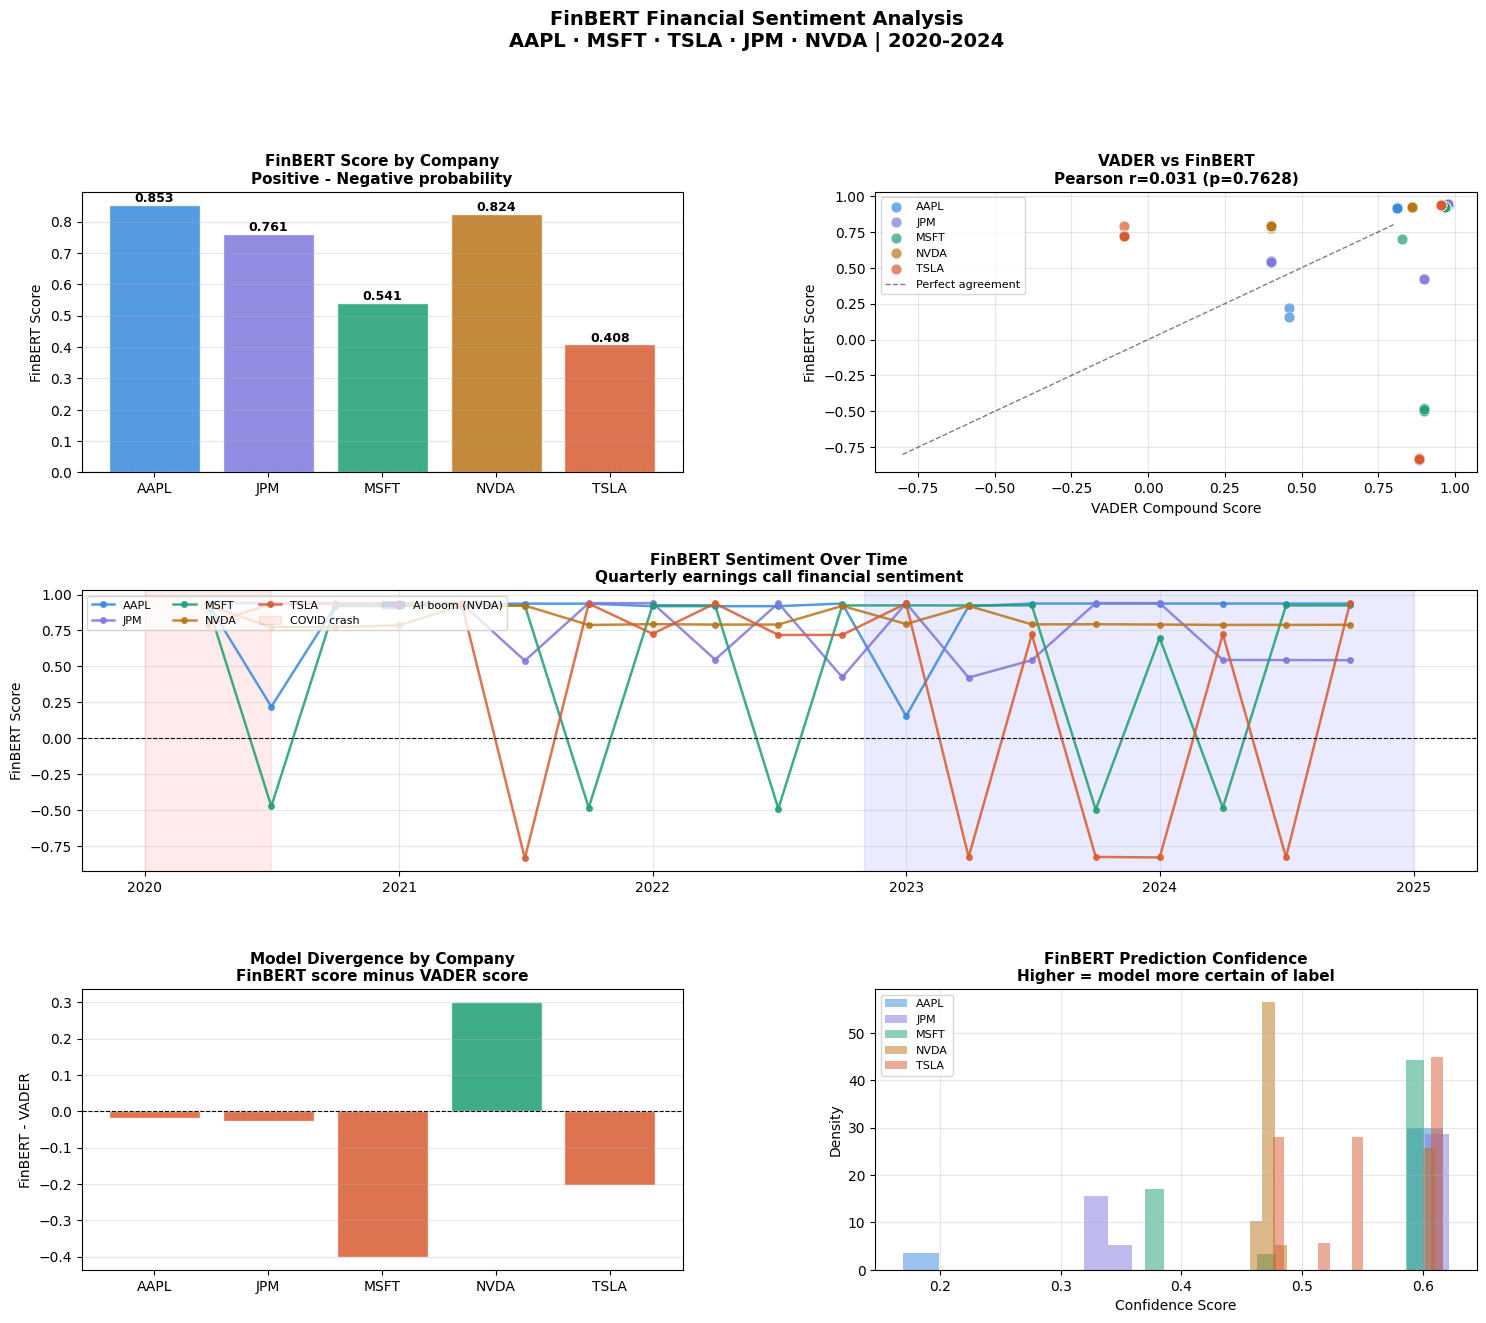

FinBERT analysis chart saved


In [5]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(
    3, 2, figure=fig,
    hspace=0.42, wspace=0.32)

# Chart 1 — FinBERT score by company
ax1 = fig.add_subplot(gs[0, 0])
company_means = compare_df.groupby("ticker")[
    "finbert_score"].mean()
colors1 = [TICKER_COLORS.get(t, "grey")
           for t in company_means.index]
bars = ax1.bar(
    company_means.index,
    company_means.values,
    color=colors1, alpha=0.85,
    edgecolor="white")
ax1.axhline(0, color="black",
            linewidth=0.8, linestyle="--")
ax1.set_title(
    "FinBERT Score by Company\n"
    "Positive - Negative probability",
    fontweight="bold", fontsize=11)
ax1.set_ylabel("FinBERT Score")
ax1.grid(alpha=0.3, axis="y")
for bar, val in zip(bars, company_means.values):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() +
        (0.01 if val >= 0 else -0.03),
        f"{val:.3f}",
        ha="center", fontsize=9,
        fontweight="bold")

# Chart 2 — VADER vs FinBERT scatter
ax2 = fig.add_subplot(gs[0, 1])
for ticker in compare_df["ticker"].unique():
    sub = compare_df[
        compare_df["ticker"]==ticker]
    ax2.scatter(
        sub["vader_compound"],
        sub["finbert_score"],
        color=TICKER_COLORS.get(ticker,"grey"),
        alpha=0.7, s=60,
        label=ticker, edgecolors="white",
        linewidths=0.5)

# Diagonal line = perfect agreement
lims = [-0.8, 0.8]
ax2.plot(lims, lims, "k--",
         linewidth=1, alpha=0.5,
         label="Perfect agreement")
ax2.set_xlabel("VADER Compound Score")
ax2.set_ylabel("FinBERT Score")
ax2.set_title(
    f"VADER vs FinBERT\n"
    f"Pearson r={corr:.3f} (p={pval:.4f})",
    fontweight="bold", fontsize=11)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

# Chart 3 — FinBERT over time by company
ax3 = fig.add_subplot(gs[1, :])
for ticker in compare_df["ticker"].unique():
    sub = compare_df[
        compare_df["ticker"]==ticker
    ].sort_values("date")
    ax3.plot(
        sub["date"],
        sub["finbert_score"],
        color=TICKER_COLORS.get(ticker,"grey"),
        linewidth=1.8, label=ticker,
        alpha=0.85, marker="o",
        markersize=4)
ax3.axhline(
    0, color="black",
    linewidth=0.8, linestyle="--")
ax3.fill_between(
    compare_df["date"].sort_values().unique(),
    0, 0, alpha=0)

# Shade key periods
ax3.axvspan("2020-01-01", "2020-06-30",
            alpha=0.08, color="red",
            label="COVID crash")
ax3.axvspan("2022-11-01", "2024-12-31",
            alpha=0.08, color="blue",
            label="AI boom (NVDA)")
ax3.set_title(
    "FinBERT Sentiment Over Time\n"
    "Quarterly earnings call financial sentiment",
    fontweight="bold", fontsize=11)
ax3.set_ylabel("FinBERT Score")
ax3.legend(fontsize=8, loc="upper left",
           ncol=4)
ax3.grid(alpha=0.3)

# Chart 4 — Model divergence by company
ax4 = fig.add_subplot(gs[2, 0])
div_company = compare_df.groupby("ticker")[
    "model_divergence"].mean()
div_colors  = [
    "#1D9E75" if v > 0 else "#D85A30"
    for v in div_company.values]
ax4.bar(div_company.index,
        div_company.values,
        color=div_colors, alpha=0.85,
        edgecolor="white")
ax4.axhline(0, color="black",
            linewidth=0.8, linestyle="--")
ax4.set_title(
    "Model Divergence by Company\n"
    "FinBERT score minus VADER score",
    fontweight="bold", fontsize=11)
ax4.set_ylabel("FinBERT - VADER")
ax4.grid(alpha=0.3, axis="y")

# Chart 5 — Confidence distribution
ax5 = fig.add_subplot(gs[2, 1])
for ticker in compare_df["ticker"].unique():
    sub = compare_df[
        compare_df["ticker"]==ticker][
        "finbert_confidence"].dropna()
    ax5.hist(sub, bins=15, alpha=0.5,
             color=TICKER_COLORS.get(ticker,"grey"),
             label=ticker, density=True)
ax5.set_title(
    "FinBERT Prediction Confidence\n"
    "Higher = model more certain of label",
    fontweight="bold", fontsize=11)
ax5.set_xlabel("Confidence Score")
ax5.set_ylabel("Density")
ax5.legend(fontsize=8)
ax5.grid(alpha=0.3)

plt.suptitle(
    "FinBERT Financial Sentiment Analysis\n"
    "AAPL · MSFT · TSLA · JPM · NVDA | 2020-2024",
    fontsize=14, fontweight="bold", y=1.01)
plt.savefig(
    "../reports/figures/finbert_analysis.png",
    dpi=150, bbox_inches="tight")
plt.show()
print("FinBERT analysis chart saved")

In [9]:
# ============================================
# FINAL COMBINED SENTIMENT DATASET
# This is what NB4 uses for return analysis
# All metrics from VADER and FinBERT merged
# ============================================

# Add sentence-level FinBERT to compare_df
sent_df["date"] = pd.to_datetime(sent_df["date"])
final_df = compare_df.merge(
    sent_df.drop(columns=["ticker"]),
    on=["date"],
    how="left"
)

# Quarter-over-quarter FinBERT change
final_df = final_df.sort_values(
    ["ticker","date"]).reset_index(drop=True)

final_df["finbert_score_lag"] = (
    final_df.groupby("ticker")[
        "finbert_score"].shift(1))
final_df["finbert_score_change"] = (
    final_df["finbert_score"] -
    final_df["finbert_score_lag"])

# Composite sentiment score
# Weighted average of both models
# FinBERT weighted higher (domain specialist)
final_df["composite_score"] = (
    0.6 * final_df["finbert_score"] +
    0.4 * final_df["vader_compound"]
)
final_df["composite_change"] = (
    0.6 * final_df["finbert_score_change"].fillna(0) +
    0.4 * final_df["vader_compound_change"].fillna(0)
)
# Remove duplicates from merge
final_df = final_df.drop_duplicates(
    subset=["ticker", "date"]
).reset_index(drop=True)

print(f"After deduplication: {len(final_df)} records")
# Save
final_df.to_csv(
    "../data/processed/sentiment_full.csv",
    index=False)

print("=" * 60)
print("   NB3 COMPLETE — FINAL SENTIMENT DATASET")
print("=" * 60)
print(f"  Total records:      {len(final_df)}")
print(f"  Features:           {len(final_df.columns)}")
print(f"\n  FinBERT score by company:")
print(final_df.groupby("ticker")[
    "finbert_score"
].agg(["mean","std"]).round(4).to_string())

print(f"\n  Composite score by company:")
print(final_df.groupby("ticker")[
    "composite_score"
].agg(["mean","std"]).round(4).to_string())

print(f"\n  VADER vs FinBERT correlation: "
      f"{corr:.4f}")
print(f"  Model divergence range: "
      f"{final_df['model_divergence'].min():.4f} "
      f"to "
      f"{final_df['model_divergence'].max():.4f}")

print(f"\n  Files saved:")
print(f"  data/processed/sentiment_full.csv")
print(f"  reports/figures/finbert_analysis.png")
print("=" * 60)
print("\nMove to 04_return_analysis.ipynb")

After deduplication: 95 records
   NB3 COMPLETE — FINAL SENTIMENT DATASET
  Total records:      95
  Features:           27

  FinBERT score by company:
          mean     std
ticker                
AAPL    0.8527  0.2351
JPM     0.7607  0.2193
MSFT    0.5411  0.6328
NVDA    0.8238  0.0610
TSLA    0.4081  0.7655

  Composite score by company:
          mean     std
ticker                
AAPL    0.8605  0.2025
JPM     0.7712  0.2244
MSFT    0.7013  0.3911
NVDA    0.7031  0.1192
TSLA    0.4890  0.4538

  VADER vs FinBERT correlation: 0.0314
  Model divergence range: -1.7198 to 0.8687

  Files saved:
  data/processed/sentiment_full.csv
  reports/figures/finbert_analysis.png

Move to 04_return_analysis.ipynb


In [7]:
# Remove duplicates from merge
final_df = final_df.drop_duplicates(
    subset=["ticker", "date"]
).reset_index(drop=True)

print(f"After deduplication: {len(final_df)} records")

After deduplication: 95 records
